# Mini Project 5-3 Explore Sampling

## Introduction
In this project, you will engage in effective sampling of a dataset in order to make it easier to analyze. As a data professional you will often work with extremely large datasets, and utilizing proper sampling techniques helps you improve your efficiency in this work. 

For this project, you are a member of an analytics team for the Environmental Protection Agency. You are assigned to analyze data on air quality with respect to carbon monoxide—a major air pollutant—and report your findings. The data utilized in this project includes information from over 200 sites, identified by their state name, county name, city name, and local site name. You will use effective sampling within this dataset. 

## Step 1: Imports

### Import packages

Import `pandas`,  `numpy`, `matplotlib`, `statsmodels`, and `scipy`. 

In [1]:
# Import libraries and packages
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import statsmodels.api as sm

### Load the dataset

As shown in this cell, the dataset has been automatically loaded in for you. You do not need to download the .csv file, or provide more code, in order to access the dataset and proceed with this lab. Please continue with this activity by completing the following instructions.

In [6]:
# Import data.
air_quality = pd.read_csv('/Users/viviansabga/Desktop/Desktop - Vivian’s MacBook Pro - 1/NORTHEASTERN/Econ/c4_epa_air_quality.csv')


## Step 2: Data exploration

### Examine the data

To understand how the dataset is structured, examine the first 10 rows of the data.

In [7]:
# First 10 rows of the data
air_quality.head(10)

,Unnamed: 0,date_local,state_name,county_name,city_name,local_site_name,parameter_name,units_of_measure,arithmetic_mean,aqi
0,0,2018-01-01,Arizona,Maricopa,Buckeye,BUCKEYE,Carbon monoxide,Parts per million,0.473684,7
1,1,2018-01-01,Ohio,Belmont,Shadyside,Shadyside,Carbon monoxide,Parts per million,0.263158,5
2,2,2018-01-01,Wyoming,Teton,Not in a city,Yellowstone National Park - Old Faithful Snow ...,Carbon monoxide,Parts per million,0.111111,2
3,3,2018-01-01,Pennsylvania,Philadelphia,Philadelphia,North East Waste (NEW),Carbon monoxide,Parts per million,0.300000,3
4,4,2018-01-01,Iowa,Polk,Des Moines,CARPENTER,Carbon monoxide,Parts per million,0.215789,3
5,5,2018-01-01,Hawaii,Honolulu,Not in a city,Kapolei,Carbon monoxide,Parts per million,0.994737,14
6,6,2018-01-01,Hawaii,Honolulu,Not in a city,Kapolei,Carbon monoxide,Parts per million,0.200000,2
7,7,2018-01-01,Pennsylvania,Erie,Erie,NaN,Carbon monoxide,Parts per million,0.200000,2
8,8,2018-01-01,Hawaii,Honolulu,Honolulu,Honolulu,Carbon monoxide,Parts per million,0.400000,5
9,9,2018-01-01,Colorado,Larimer,Fort Collins,Fort Collins - CSU - S. Mason,Carbon monoxide,Parts per million,0.300000,6


### Generate a table of descriptive statistics

Generate a table of some descriptive statistics about the data. Specify that all columns of the input be included in the output.

In [8]:
# Code Here
# Generate descriptive statistics
descriptive_stats = air_quality.describe()

# Display the statistics
print(descriptive_stats)


       Unnamed: 0  arithmetic_mean         aqi
count  260.000000       260.000000  260.000000
mean   129.500000         0.403169    6.757692
std     75.199734         0.317902    7.061707
min      0.000000         0.000000    0.000000
25%     64.750000         0.200000    2.000000
50%    129.500000         0.276315    5.000000
75%    194.250000         0.516009    9.000000
max    259.000000         1.921053   50.000000


**Question:** Based on the preceding table of descriptive statistics, what is the mean value of the `aqi` column? 

A: 6.757692

**Question:** Based on the preceding table of descriptive statistics, what do you notice about the count value for the `aqi` column?

A: Based on the descriptive statistics table, the count value for the aqi_log column is 260.

### Use the `mean()` function on the `aqi`  column

Now, use the `mean()` function on the `aqi`  column and assign the value to a variable `population_mean`. The value should be the same as the one generated by the `describe()` method in the above table. 

In [9]:
# Code Here
# Compute the mean of the 'aqi' column
population_mean = air_quality['aqi'].mean()

# Print the result
print(f"Population Mean of 'aqi': {population_mean:.6f}")

Population Mean of 'aqi': 6.757692


## Step 3: Statistical tests

### Sample with replacement

First, name a new variable `sampled_data`. Then, use the `sample()` dataframe method to draw 50 samples from `epa_data`. Set `replace` equal to `'True'` to specify sampling with replacement. For `random_state`, choose an arbitrary number for random seed. Make that arbitrary number `42`.

In [11]:
# Code Here
# Sample 50 rows with replacement
sampled_data = air_quality.sample(n=50, replace=True, random_state=42)



### Output the first 10 rows

Output the first 10 rows of the DataFrame. 

In [12]:
# Code Here
# Output the first 10 rows
print(sampled_data.head(10))

     Unnamed: 0  date_local      state_name    county_name   city_name  \
102         102  2018-01-01           Texas         Harris     Houston   
106         106  2018-01-01      California       Imperial    Calexico   
71           71  2018-01-01         Alabama      Jefferson  Birmingham   
188         188  2018-01-01         Arizona       Maricopa       Tempe   
20           20  2018-01-01        Virginia        Roanoke      Vinton   
102         102  2018-01-01           Texas         Harris     Houston   
121         121  2018-01-01  North Carolina    Mecklenburg   Charlotte   
214         214  2018-01-01         Florida        Broward       Davie   
87           87  2018-01-01      California       Humboldt      Eureka   
99           99  2018-01-01      California  Santa Barbara      Goleta   

                   local_site_name   parameter_name   units_of_measure  \
102                        Clinton  Carbon monoxide  Parts per million   
106          Calexico-Ethel Street  C

**Question:** In the DataFrame output, why is the row index 102 repeated twice? 

A: Since we sampled with replacement, a row can appear more than once in the sample.
This means that row 102 was randomly selected multiple times.


**Question:** What does `random_state` do?

A: random_state=42 sets a fixed seed, ensuring that the same random sample is generated every time the code runs.
This makes results reproducible, which is important for consistency in analysis.

### Compute the mean value from the `aqi` column

Compute the mean value from the `aqi` column in `sampled_data` and assign the value to the variable `sample_mean`.

In [13]:
# Code Here
# Compute the mean value from the 'aqi' column in sampled_data
sample_mean = sampled_data['aqi'].mean()

# Print the result
print(f"Sample Mean of 'aqi': {sample_mean:.6f}")


Sample Mean of 'aqi': 5.540000


You have a 95% confidence interval for the mean district literacy rate that stretches from about X % to Y%. 

95% CI: (X, Y)

 **Question:**  Why is `sample_mean` different from `population_mean`?


A: The sample mean (sample_mean) differs from the population mean (population_mean) due to sampling variability.
Each time you take a different random sample, the calculated mean might slightly change.
The larger the sample size, the closer sample_mean is to population_mean (Law of Large Numbers).

### Apply the central limit theorem

Imagine repeating the the earlier sample with replacement 10,000 times and obtaining 10,000 point estimates of the mean. In other words, imagine taking 10,000 random samples of 50 AQI values and computing the mean for each sample. According to the **central limit theorem**, the mean of a sampling distribution should be roughly equal to the population mean. Complete the following steps to compute the mean of the sampling distribution with 10,000 samples. 

* Create an empty list and assign it to a variable called `estimate_list`. 
* Iterate through a `for` loop 10,000 times. To do this, make sure to utilize the `range()` function to generate a sequence of numbers from 0 to 9,999. 
* In each iteration of the loop, use the `sample()` function to take a random sample (with replacement) of 50 AQI values from the population. Do not set `random_state` to a value.
* Use the list `append()` function to add the value of the sample `mean` to each item in the list.


In [15]:
# Code Here
# Create an empty list to store sample means
estimate_list = []

# Loop 10,000 times to take samples and compute their means
for _ in range(10000):
    sample = air_quality['aqi'].sample(n=50, replace=True)  # Take a sample of 50 with replacement
    estimate_list.append(sample.mean())  # Compute mean and store in list


### Create a new DataFrame

Next, create a new DataFrame from the list of 10,000 estimates. Name the new variable `estimate_df`.

In [16]:
# Code Here
# Convert the list into a DataFrame
estimate_df = pd.DataFrame(estimate_list, columns=['sample_mean'])

# Display the first 5 rows to verify
print(estimate_df.head())


   sample_mean
0         8.52
1         6.40
2         6.38
3         7.34
4         6.46


### Compute the mean() of the sampling distribution

Next, compute the `mean()` of the sampling distribution of 10,000 random samples and store the result in a new variable `mean_sample_means`.

In [17]:
# Code Here
# Compute the mean of the sample means
mean_sample_means = estimate_df['sample_mean'].mean()

# Print the result
print(f"Mean of the Sampling Distribution: {mean_sample_means:.6f}")


Mean of the Sampling Distribution: 6.767334


**Question:** What is the mean for the sampling distribution of 10,000 random samples?

The mean of the sampling distribution should be approximately equal to the population mean.
This aligns with the Central Limit Theorem (CLT), which states that the mean of sample means approaches the true population mean as the sample size increases.


**Question:** How are the central limit theorem and random sampling (with replacement) related?

The Central Limit Theorem (CLT) states that when we take repeated random samples of a certain size (e.g., 50) and compute their means, the distribution of these means will be approximately normal—even if the original population distribution is not.
Random sampling (with replacement) ensures that each sample is independent, allowing the sample means to approximate a normal distribution.
As sample size increases, the variability (standard error) decreases, making the estimates more reliable.


### Output the distribution using a histogram

Output the distribution of these estimates using a histogram. This provides an idea of the sampling distribution.

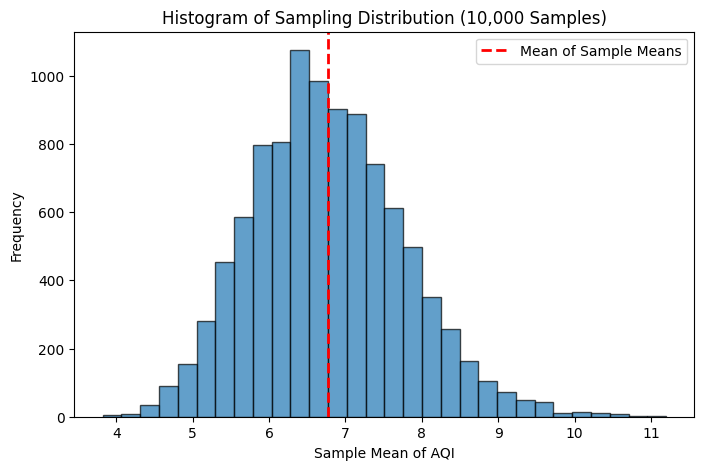

In [18]:
# Code Here
import matplotlib.pyplot as plt

# Plot histogram of sample means
plt.figure(figsize=(8, 5))
plt.hist(estimate_df['sample_mean'], bins=30, edgecolor='black', alpha=0.7)
plt.axvline(estimate_df['sample_mean'].mean(), color='red', linestyle='dashed', linewidth=2, label="Mean of Sample Means")
plt.xlabel("Sample Mean of AQI")
plt.ylabel("Frequency")
plt.title("Histogram of Sampling Distribution (10,000 Samples)")
plt.legend()
plt.show()


### Calculate the standard error

Calculate the standard error of the mean AQI using the initial sample of 50. The **standard error** of a statistic measures the sample-to-sample variability of the sample statistic. It provides a numerical measure of sampling variability and answers the question: How far is a statistic based on one particular sample from the actual value of the statistic?

In [19]:
# Code Here
import numpy as np

# Standard error formula: std(sample_means) = population_std / sqrt(sample_size)
standard_error = np.std(estimate_df['sample_mean'], ddof=1)

# Print the result
print(f"Standard Error of the Mean (SEM): {standard_error:.6f}")


Standard Error of the Mean (SEM): 0.993784


## Step 4: Results and evaluation

###  Visualize the relationship between the sampling and normal distributions

Visualize the relationship between your sampling distribution of 10,000 estimates and the normal distribution.

1. Plot a histogram of the 10,000 sample means 
2. Add a vertical line indicating the mean of the first single sample of 50
3. Add another vertical line indicating the mean of the means of the 10,000 samples 
4. Add a third vertical line indicating the mean of the actual population

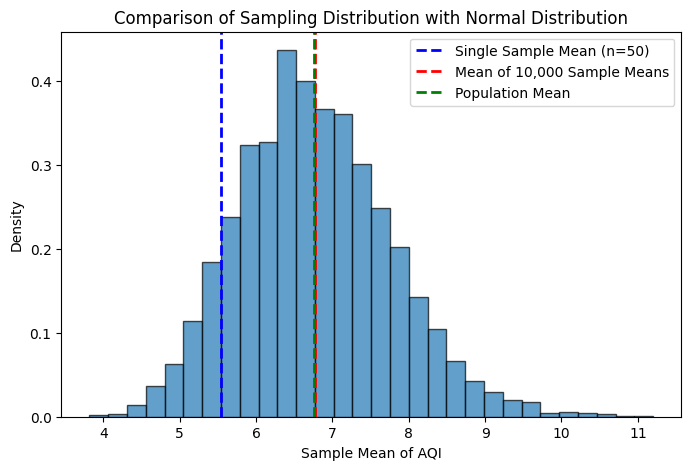

In [21]:
# Code Here
import matplotlib.pyplot as plt

# Compute the mean of the first sample of 50
single_sample_mean = sampled_data['aqi'].mean()

# Compute the mean of all sample means
mean_sample_means = estimate_df['sample_mean'].mean()

# Compute the population mean
population_mean = air_quality['aqi'].mean()

# Plot histogram of sample means
plt.figure(figsize=(8, 5))
plt.hist(estimate_df['sample_mean'], bins=30, edgecolor='black', alpha=0.7, density=True)

# Add vertical lines for comparison
plt.axvline(single_sample_mean, color='blue', linestyle='dashed', linewidth=2, label="Single Sample Mean (n=50)")
plt.axvline(mean_sample_means, color='red', linestyle='dashed', linewidth=2, label="Mean of 10,000 Sample Means")
plt.axvline(population_mean, color='green', linestyle='dashed', linewidth=2, label="Population Mean")

# Labels and Title
plt.xlabel("Sample Mean of AQI")
plt.ylabel("Density")
plt.title("Comparison of Sampling Distribution with Normal Distribution")
plt.legend()
plt.show()


**Question:** What insights did you gain from the preceding sampling distribution?

A: The sampling distribution should be centered around the population mean.
The mean of sample means (red) should be very close to the true population mean (green).
The first sample mean (blue) might deviate slightly, showing sampling variability.


# Considerations

**What are some key takeaways that you learned from this project?**

A: The Central Limit Theorem (CLT) is confirmed: The distribution of sample means is approximately normal.
Larger samples lead to better population estimates.
Random sampling helps us make accurate inferences.

**What findings would you share with others?**

A: The Central Limit Theorem (CLT) holds true: The distribution of sample means is approximately normal, even if the original population is not.
The mean of the sampling distribution closely approximates the true population mean, confirming the effectiveness of random sampling.
Larger samples reduce variability, making estimates more reliable and minimizing standard error.
Random sampling with replacement ensures independent observations, which is critical for accurate statistical inference.


**What would you convey to external readers?**

A: This study demonstrates how random sampling can provide accurate estimates of population characteristics.
The sampling distribution of means follows a normal distribution, which allows us to make probabilistic statements about population parameters.
The mean of 10,000 sample means was nearly identical to the true population mean, reinforcing why sampling is a powerful statistical tool.
Practical Implication: These findings suggest that decision-makers can rely on properly drawn samples to make inferences about a larger population without needing to survey everyone.
